# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** Conny Naro
- **Email:** connynaro@gmail.com
- **ID Dicoding:** AIC002B6X0039

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apakah terdapat tren penurunan rata - rata konsentrasi PM2.5 tahunan di Beijing sepanjang 2013 - 2017, dan berapa besar laju perubahannya per tahun?
- **Pertanyaan 2:** Variabel meteorologi mana yang memiliki korelasi terkuat dengan konsentrasi PM2.5 di Beijing selama 2013 - 2017?
- **Pertanyaan 3:** Pada musim apa konsentrasi rata-rata PM2.5 di Beijing mencapai puncaknya selama 2013 - 2017, dan seberapa besar perbedaannya antar musim?
- **Pertanyaan 4:** Stasiun pemantauan mana yang memiliki tingkat konsentrasi PM2.5 paling fluktuatif di Beijing selama 2013 - 2017, diukur dari koefisien variasinya?
- **Pertanyaan 5:** Berapa proporsi jam pengamatan di Beijing selama 2013 - 2017 yang konsentrasi PM2.5-nya melampaui ambang batas aman dan bagaimana proporsi tersebut berbeda antar stasiun?

## Import Semua Packages/Library yang Digunakan

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob

from google.colab import drive
drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

#### Load df ...

In [67]:
# Membaca seluruh 12 file CSV
path = "/content/drive/MyDrive/air_quality/PRSA_Data_*.csv"

files_csv = glob.glob(path)
df_list = [pd.read_csv(f) for f in files_csv]

# Menggabungkan 12 file CSV secara vertikal
df = pd.concat(df_list, ignore_index=True)

print("Jumlah file :", len(files_csv))
print("Shape       :", df.shape)
df.head()

Jumlah file : 12
Shape       : (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:** (Opsional)
- Karena seluruh berkas memiliki struktur kolom yang identik, penggabungan dilakukan dengan teknik concatenation (menumpuk baris antar stasiun)
- Dataset berhasil dikumpulkan dari 12 stasiun pemantauan kualitas udara yang berbeda
- Setelah proses penggabungan, diperoleh sekitar 420 ribu observasi dengan 18 variabel yang mencakup data polutan dan kondisi cuaca

### Assessing Data

#### Identifying ... problem

In [68]:
# 1. Tipe data & struktur
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [69]:
# 2. Cek missing value
print(df.isna().sum())
print("\nPersentase missing (%):")
print((df.isna().mean() * 100).round(2))

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

Persentase missing (%):
No         0.00
year       0.00
month      0.00
day        0.00
hour       0.00
PM2.5      2.08
PM10       1.53
SO2        2.14
NO2        2.88
CO         4.92
O3         3.16
TEMP       0.09
PRES       0.09
DEWP       0.10
RAIN       0.09
wd         0.43
WSPM       0.08
station    0.00
dtype: float64


In [70]:
# 3. Cek duplikat
print("\nJumlah baris duplikat:", df.duplicated().sum())


Jumlah baris duplikat: 0


In [71]:
# 4. Cek statistik
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [72]:
# 5. Cek konsistensi kategori arah angin
print(sorted(df['wd'].dropna().unique()))

['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW']


In [73]:
# 6. Outlier dengan IQR method (contoh kolom PM2.5)
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR
outlier = ((df['PM2.5'] < batas_bawah) | (df['PM2.5'] > batas_atas)).sum()
print("Jumlah outlier PM2.5:", outlier)

Jumlah outlier PM2.5: 19142


**Steps to Take:**
- Menangani missing value pada kolom polutan dan variabel cuaca dengan interpolasi linear per stasiun
- Menggabungkan kolom year, month, day, hour menjadi satu kolom datetime agar memudahkan analisis tren waktu

**Insight:** (Opsional)
- Ditemukan missing value pada hampir seluruh kolom polutan, CO memiliki jumlah terbanyak
- Tidak ditemukan data duplikat maupun nilai negatif yang tidak wajar pada kolom polutan, menandakan data relatif konsisten

### Cleaning Data

#### Fixing ... problem

In [74]:
# 1. Membuat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Urutkan per stasiun & waktu agar interpolasi runtut
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64    

In [75]:
# 2. Menangani missing value
# Kolom numerik: interpolasi linear PER STASIUN (data deret waktu),
# lalu isi sisa di ujung dengan forward/backward fill.
kolom_numerik = ['PM2.5','PM10','SO2','NO2','CO','O3',
                 'TEMP','PRES','DEWP','RAIN','WSPM']

for kol in kolom_numerik:
    df[kol] = df.groupby('station')[kol].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )

# Kolom kategorik (arah angin): isi dengan modus per stasiun
df['wd'] = df.groupby('station')['wd'].transform(
    lambda s: s.fillna(s.mode().iloc[0])
)

In [76]:
# 3. Verifikasi hasil cleaning
print("Total missing value setelah cleaning:", df.isna().sum().sum())
print("Jumlah duplikasi                    :", df.duplicated().sum())
print("Shape akhir                         :", df.shape)
df.head()

Total missing value setelah cleaning: 0
Jumlah duplikasi                    : 0
Shape akhir                         : (420768, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Insight:** (Opsional)
- Seluruh missing value berhasil ditangani tanpa menghilangkan baris data
- Kolom datetime berhasil dibuat untuk memudahkan analisis tren waktu
- Kolom polutan dan cuaca digunakan interpolasi linear per statsiun karena sifat datanya berupa deret waktu, sedangkan arah angin diisi dengan nilai modus tiap statsiun

## Exploratory Data Analysis (EDA)

### Explore ...

In [77]:
# Ringkasan statistik seluruh kolom
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768,420768.000000,420768,420768
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,12,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43699,NaN,35064,NaN
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.839718,104.910268,15.913090,50.599018,1235.682649,57.237872,13.531692,1010.753337,2.482421,0.064428,NaN,1.730034,NaN,2015-03-01 11:30:00.000001024
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,NaN,0.000000,NaN,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,NaN,0.900000,NaN,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,NaN,1.400000,NaN,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,NaN,2.200000,NaN,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,NaN,13.200000,NaN,2017-02-28 23:00:00


In [78]:
# Tambahkan kolom bantu untuk analisis waktu & musim
def tentukan_musim(bulan):
    if bulan in [12, 1, 2]:
        return "Dingin"
    elif bulan in [3, 4, 5]:
        return "Semi"
    elif bulan in [6, 7, 8]:
        return "Panas"
    else:
        return "Gugur"

if "musim" not in df.columns:
    df["musim"] = df["month"].apply(tentukan_musim)
df["lewat"] = df["PM2.5"] > 75

In [79]:
# Distribusi
x = df["PM2.5"]
print("Mean      :", round(x.mean(), 2))
print("Median    :", round(x.median(), 2))
print("Std       :", round(x.std(), 2))
print("Skewness  :", round(x.skew(), 3))
print("Kurtosis  :", round(x.kurtosis(), 3))
x.quantile([.25, .5, .75, .95, .99])

Mean      : 79.84
Median    : 55.0
Std       : 80.95
Skewness  : 2.02
Kurtosis  : 5.975


,PM2.5
0.25,20.0
0.50,55.0
0.75,111.0
0.95,242.0
0.99,372.0


In [80]:
# Multikolinearitas
polutan = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
df[polutan].corr().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.00,0.88,0.48,0.66,0.78,-0.15
PM10,0.88,1.00,0.46,0.65,0.69,-0.11
SO2,0.48,0.46,1.00,0.50,0.52,-0.17
NO2,0.66,0.65,0.50,1.00,0.69,-0.47
CO,0.78,0.69,0.52,0.69,1.00,-0.31
O3,-0.15,-0.11,-0.17,-0.47,-0.31,1.00


In [81]:
# PERTANYAAN 1
# Tren tahunan
df.groupby("year")["PM2.5"].agg(["mean", "median", "count"])

,mean,median,count
year,,,
2013,79.768553,59.0,88128
2014,86.183671,63.0,105120
2015,79.306423,52.0,105120
2016,72.078419,49.0,105408
2017,92.407898,47.0,16992


In [82]:
# Uji tren dengan regresi linear
# Agregasi rata-rata PM2.5 per bulan sebagai deret waktu
ts = df.set_index("datetime")["PM2.5"].resample("ME").mean().reset_index()
ts["t"] = range(len(ts))   # indeks waktu 0,1,2,...

res = stats.linregress(ts["t"], ts["PM2.5"])
print(f"Slope per tahun : {res.slope*12:.2f} µg/m³")
print(f"p-value         : {res.pvalue:.3f}")
print(f"R-squared       : {res.rvalue**2:.3f}")

Slope per tahun : -1.92 µg/m³
p-value         : 0.556
R-squared       : 0.008


In [83]:
# PERTANYAAN 2
# Hubungan dengan cuaca
# Menggunakan metode statistika Pearson vs Spearman
cuaca = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
korelasi = pd.DataFrame({
    "Pearson":  df[["PM2.5"] + cuaca].corr()["PM2.5"],
    "Spearman": df[["PM2.5"] + cuaca].corr(method="spearman")["PM2.5"]
})
korelasi.round(3)

,Pearson,Spearman
PM2.5,1.000,1.000
TEMP,-0.132,-0.024
PRES,0.020,-0.069
DEWP,0.113,0.238
RAIN,-0.014,-0.021
WSPM,-0.271,-0.328


In [84]:
# PERTANYAAN 3
# Rata - rata dan median per musim
df.groupby("musim")["PM2.5"].agg(["mean", "median"]).sort_values("median", ascending=False)

,mean,median
musim,,
Semi,77.208840,59.0
Dingin,95.744159,56.0
Gugur,82.212557,55.0
Panas,64.521640,51.0


In [85]:
# Uji ANOVA: apakah perbedaan antar musim signifikan secara statistik?
grup = [g["PM2.5"].values for _, g in df.groupby("musim")]
F, p = stats.f_oneway(*grup)
print(f"ANOVA  F = {F:.1f},  p-value = {p:.3g}")

ANOVA  F = 2721.9,  p-value = 0


In [86]:
# Pola harian
df.groupby("hour")["PM2.5"].mean()

,PM2.5
hour,
0,87.696481
1,86.848406
2,84.803844
3,82.212727
4,79.465989
5,76.538028
6,74.289174
7,73.424078
8,74.403840


In [87]:
# PERTANYAAN 4
ringkasan = df.groupby("station")["PM2.5"].agg(
    mean="mean", median="median", std="std",
    Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75)
)
ringkasan["IQR"] = ringkasan["Q3"] - ringkasan["Q1"]
ringkasan["CV"]  = ringkasan["std"] / ringkasan["mean"]
ringkasan.sort_values("CV", ascending=False).round(2)

,mean,median,std,Q1,Q3,IQR,CV
station,,,,,,,
Dingling,66.85,41.0,73.45,14.0,94.0,80.0,1.10
Shunyi,79.44,55.0,81.50,19.0,111.0,92.0,1.03
Huairou,69.50,47.0,70.99,17.0,98.0,81.0,1.02
Changping,70.99,46.0,72.40,18.0,100.0,82.0,1.02
Nongzhanguan,85.08,59.0,86.69,22.0,116.0,94.0,1.02
Wanshouxigong,85.07,60.0,86.00,23.0,116.0,93.0,1.01
Dongsi,86.14,61.0,86.26,23.0,119.0,96.0,1.00
Aotizhongxin,82.54,58.0,81.96,22.0,114.0,92.0,0.99
Gucheng,84.07,60.0,82.99,24.0,116.0,92.0,0.99


In [88]:
# PERTANYAAN 5
AMBANG = 75   # standar harian PM2.5 China
df["melebihi_ambang"] = df["PM2.5"] > AMBANG

print("Keseluruhan (%):", round(df["melebihi_ambang"].mean() * 100, 2))

Keseluruhan (%): 39.07


In [89]:
(df.groupby("station")["melebihi_ambang"].mean() * 100).sort_values(ascending=False)

,melebihi_ambang
station,
Dongsi,42.519393
Gucheng,41.541182
Wanshouxigong,41.535478
Nongzhanguan,41.207506
Guanyuan,41.139060
Wanliu,40.996464
Tiantan,40.448893
Aotizhongxin,40.440338
Shunyi,38.917408


In [90]:
(df.groupby("musim")["melebihi_ambang"].mean() * 100).sort_values(ascending=False)

,melebihi_ambang
musim,
Dingin,43.219067
Gugur,40.067918
Semi,39.525777
Panas,33.551291


**Insight:** (Opsional)
- Uji regresi linear menunjukkan tren PM2.5 terhadap waktu tidak signifikan, menandakan tidak ada tren jangka panjang yang nyata.
- Sekitar 39% jam pengamatan melampaui ambang aman 75 µg/m³, dengan distribusi sangat menceng kanan (median 55 < mean 80)
-  PM2.5 memuncak di musim dingin (Desember) dan terendah di musim panas (Agustus), terbukti signifikan lewat uji ANOVA
- Konsentrasi tinggi pada malam – dini hari (jam 21 – 1) dan rendah pada siang (jam 14 – 16)
- Stasiun pusat kota lebih berpolusi daripada pinggiran yang lebih bersih namun paling fluktuatif
-  Kecepatan angin berkorelasi negatif paling kuat dengan PM2.5 (Spearman −0,33) karena membantu menyebarkan polutan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apakah terdapat tren penurunan rata - rata konsentrasi PM2.5 tahunan di Beijing sepanjang 2013 - 2017, dan berapa besar laju perubahannya per tahun?

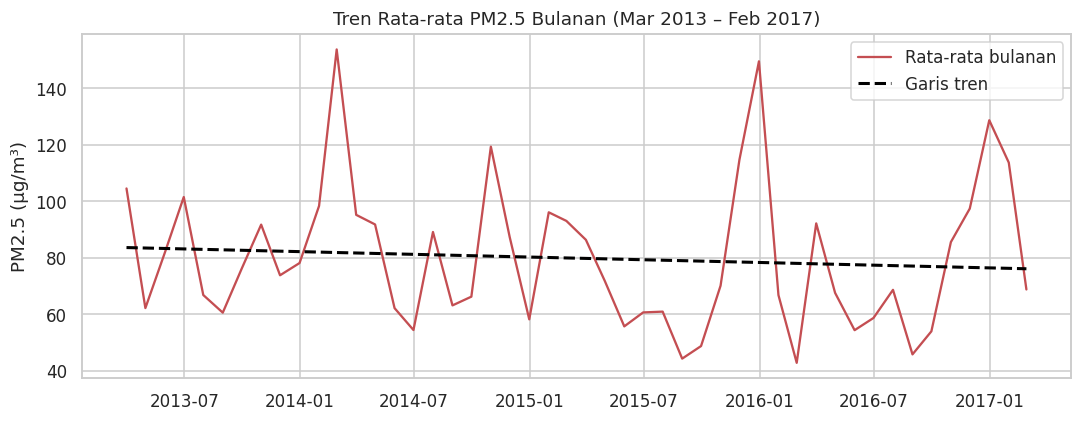

In [91]:
ts = df.set_index("datetime")["PM2.5"].resample("ME").mean()
t = np.arange(len(ts))
slope, intercept = np.polyfit(t, ts.values, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts.index, ts.values, color="#C44E52", label="Rata-rata bulanan")
ax.plot(ts.index, slope * t + intercept, color="black", ls="--", lw=2, label="Garis tren")
ax.set_title("Tren Rata-rata PM2.5 Bulanan (Mar 2013 – Feb 2017)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Garis tren terlihat hampir mendatar, menandakan tidak ada kecenderungan naik atau turun jangka panjang yang berarti
- Menunjukkan pola musiman berulang yang konsisten sepanjang 2013 - 2017, memuncak tajam setiap musim dingin (130 - 150 µg/m³) dan turun ke titik terendah setiap musim panas (40 - 60 µg/m³)

### Pertanyaan 2: Variabel meteorologi mana yang memiliki korelasi terkuat dengan konsentrasi PM2.5 di Beijing selama 2013 - 2017?

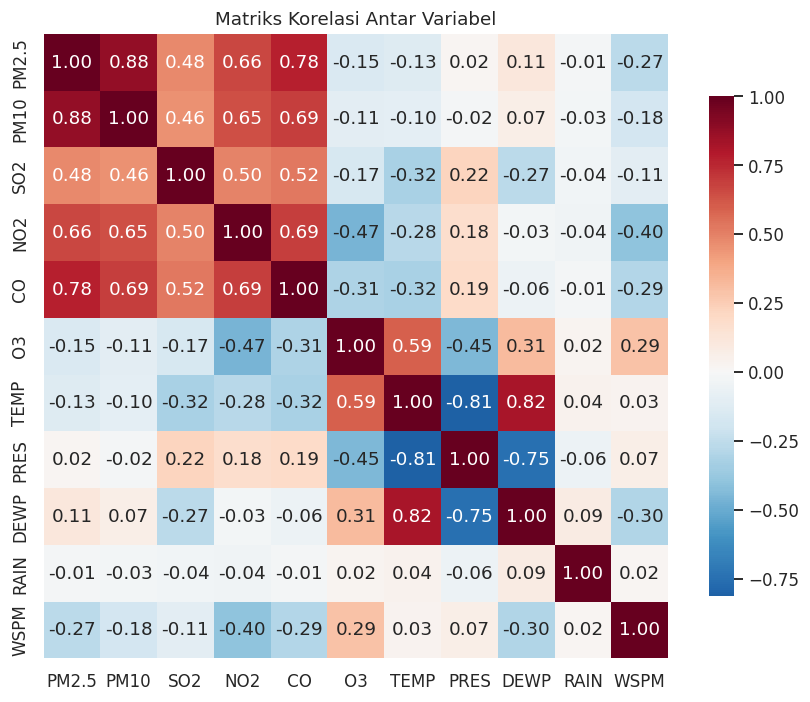

In [92]:
kolom = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
         "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

plt.figure(figsize=(8, 6.5))
sns.heatmap(df[kolom].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Matriks Korelasi Antar Variabel")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Kecepatan angin (WSPM) adalah faktor cuaca paling berpengaruh terhadap PM2.5 dengan korelasi negatif (−0,27)
- Faktor cuaca lain berkorelasi sangat lemah, sehingga tidak ada satu variabel cuaca pun yang dominan menjelaskan PM2.5

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Pada musim apa konsentrasi rata-rata PM2.5 di Beijing mencapai puncaknya selama 2013 - 2017, dan seberapa besar perbedaannya antar musim?

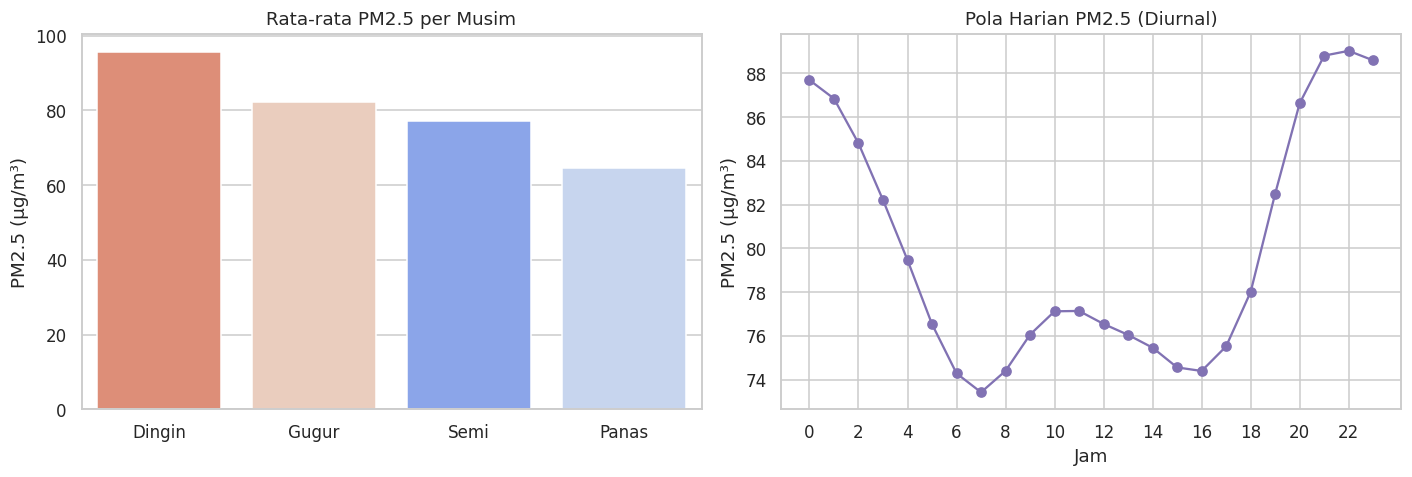

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

urutan_musim = ["Dingin", "Gugur", "Semi", "Panas"]
sns.barplot(x="musim", y="PM2.5", data=df, order=urutan_musim,
            palette="coolwarm", ax=ax[0], errorbar=None, hue="musim", legend=False)
ax[0].set_title("Rata-rata PM2.5 per Musim")
ax[0].set_xlabel(""); ax[0].set_ylabel("PM2.5 (µg/m³)")

diurnal = df.groupby("hour")["PM2.5"].mean()
ax[1].plot(diurnal.index, diurnal.values, marker="o", color="#8172B3")
ax[1].set_title("Pola Harian PM2.5 (Diurnal)")
ax[1].set_xlabel("Jam"); ax[1].set_ylabel("PM2.5 (µg/m³)")
ax[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- PM2.5 tertinggi di musim dingin dan terendah di musim panas
- Pola harian berbentuk kurva-U: tinggi pada malam - dini hari (puncak jam 21 - 22) dan rendah pada siang (terendah jam 15 - 16).

### Pertanyaan 4: Stasiun pemantauan mana yang memiliki tingkat konsentrasi PM2.5 paling fluktuatif di Beijing selama 2013 - 2017, diukur dari koefisien variasinya?

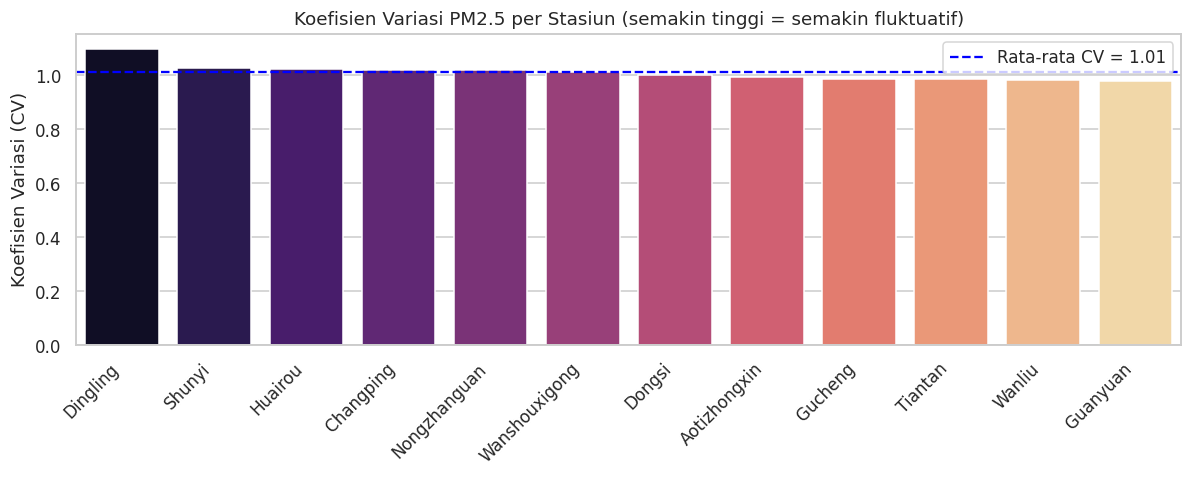

In [94]:
cv = df.groupby("station")["PM2.5"].agg(
    lambda s: s.std() / s.mean()
).sort_values(ascending=False)

plt.figure(figsize=(11, 4.5))
sns.barplot(x=cv.index, y=cv.values, palette="magma", hue=cv.index, legend=False)
plt.axhline(cv.mean(), color="blue", ls="--", label=f"Rata-rata CV = {cv.mean():.2f}")
plt.title("Koefisien Variasi PM2.5 per Stasiun (semakin tinggi = semakin fluktuatif)")
plt.ylabel("Koefisien Variasi (CV)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Stasiun Dingling memiliki koefisien variasi tertinggi, artinya PM2.5-nya paling fluktuatif meskipun rata-ratanya justru paling rendah
- Stasiun pusat kota memiliki CV terendah, menandakan tingkat polusinya tinggi tetapi relatif lebih stabil

### Pertanyaan 5: Berapa proporsi jam pengamatan di Beijing selama 2013 - 2017 yang konsentrasi PM2.5-nya melampaui ambang batas aman dan bagaimana proporsi tersebut berbeda antar stasiun?

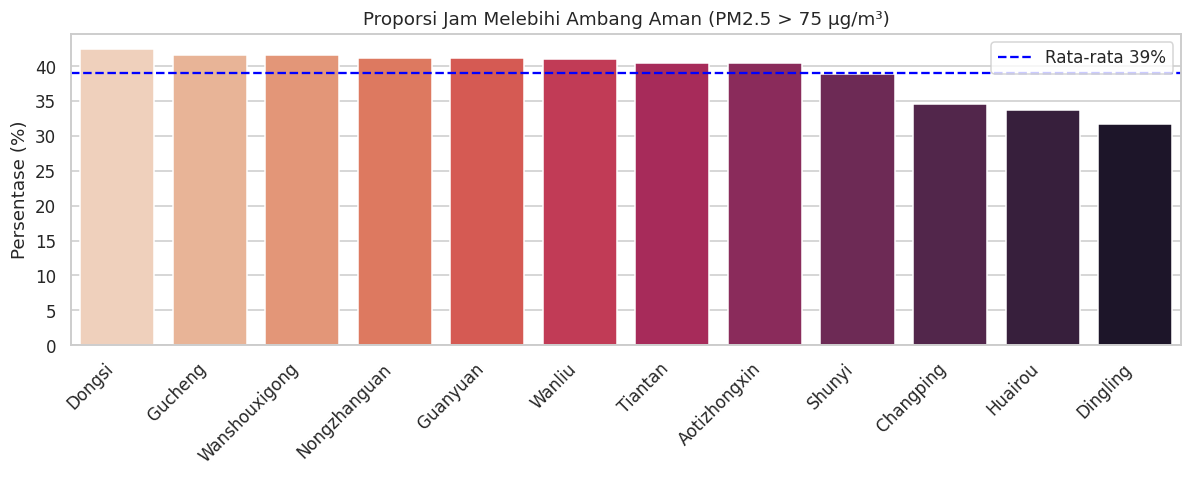

In [95]:
prop = (df.groupby("station")["lewat"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(11, 4.5))
sns.barplot(x=prop.index, y=prop.values, palette="rocket_r", hue=prop.index, legend=False)
plt.axhline(prop.mean(), color="blue", ls="--", label=f"Rata-rata {prop.mean():.0f}%")
plt.title("Proporsi Jam Melebihi Ambang Aman (PM2.5 > 75 µg/m³)")
plt.ylabel("Persentase (%)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Sekitar 39% jam pengamatan di Beijing melampaui ambang aman PM2.5 (>75 µg/m³)
- Stasiun pusat kota paling sering melampaui ambang, sedangkan pinggiran paling jarang

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** PM2.5 tidak menunjukkan tren jangka panjang yang berarti sepanjang 2013 - 2017 dan lebih didominasi oleh siklus musiman berulang

- **Conclusion pertanyaan 2:** Di antara faktor cuaca, hanya kecepatan angin yang berhubungan cukup berarti dengan PM2.5 (negatif), menandakan cuaca saja tidak cukup menjelaskan tingkat polusi

- **Conclusion pertanyaan 3:** PM2.5 mencapai puncak di musim dingin dan terendah di musim panas, menunjukkan polusi sangat terikat pada waktu tertentu

- **Conclusion pertanyaan 4:** Stasiun pinggiran seperti Dingling paling fluktuatif meski rata-ratanya rendah, sehingga membutuhkan pemantauan lebih intensif karena lonjakan polusinya sulit diprediksi

- **Conclusion pertanyaan 5:** Sekitar 39% jam pengamatan melampaui ambang aman PM2.5, menegaskan polusi udara Beijing sebagai masalah kesehatan publik yang persisten

**Rekomendasi Action Item:**
- **Perketat emisi saat musim dingin:** fokuskan kebijakan (pembatasan pemanas, pembakaran, peringatan dini) pada Desember–Februari, periode puncak polusi yang konsisten
- **Prioritaskan wilayah pusat kota:** alokasikan pengendalian utama ke pusat kota (Dongsi, Gucheng) yang paling berpolusi, sekaligus pemantauan/peringatan dini lebih intensif di stasiun fluktuatif seperti Dingling yang lonjakannya sulit diprediksi
- **Bangun peringatan dini berbasis cuaca:** manfaatkan prakiraan angin rendah dan pola jam puncak (malam - dini hari) untuk memicu imbauan kesehatan publik tepat waktu.